Loading host experiments...
  ✅ Scenario1
  ✅ Scenario2
  ✅ Scenario3
3 host experiment(s) loaded.



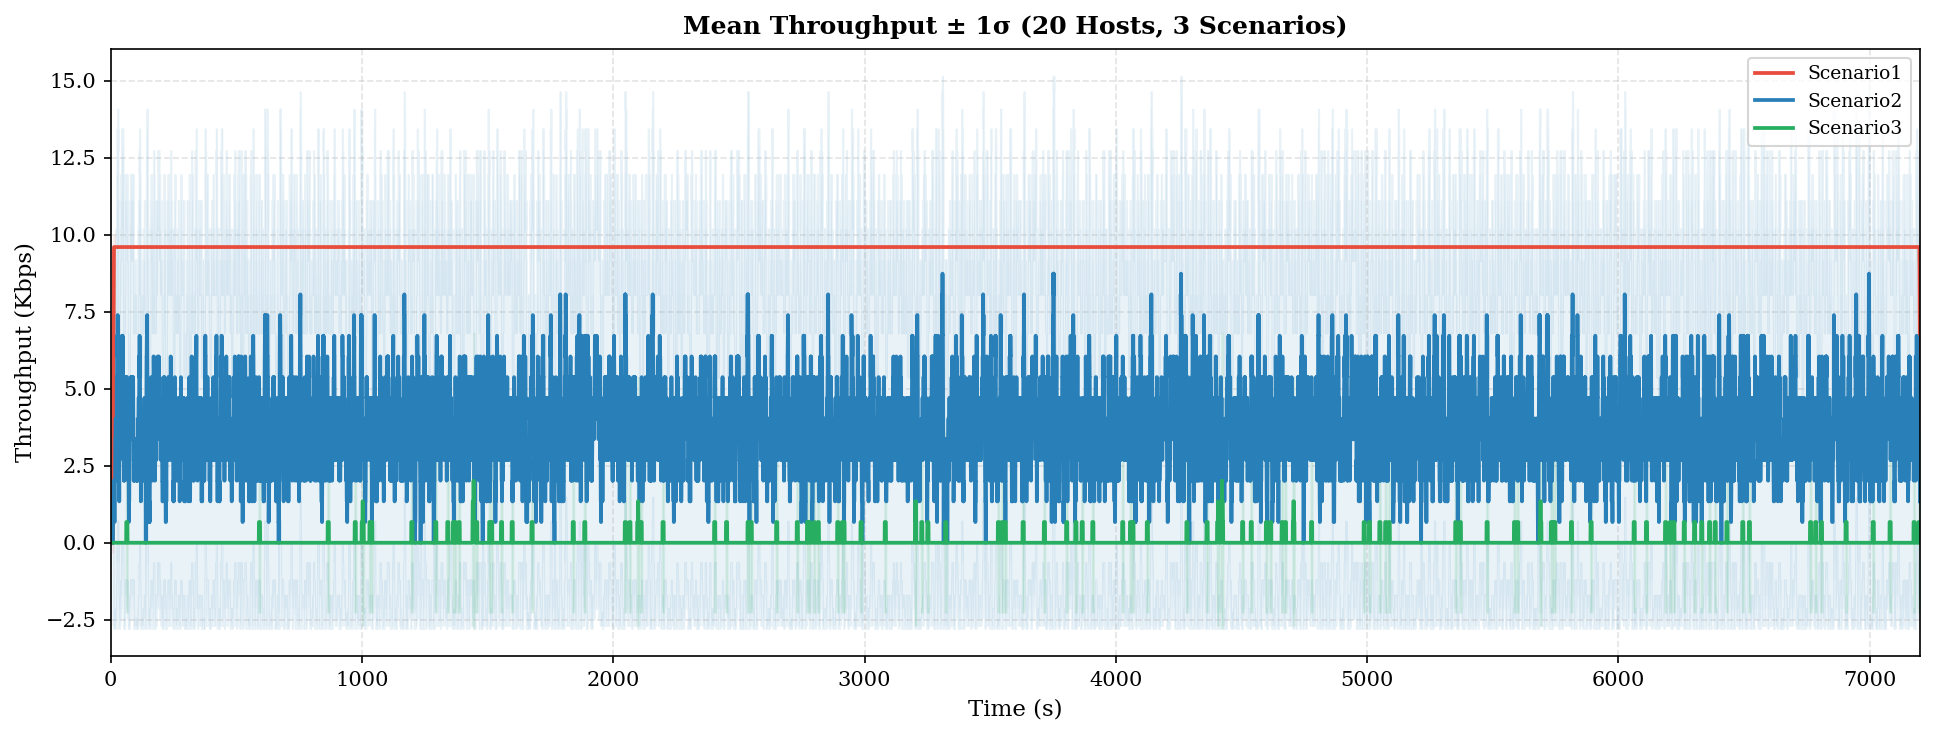

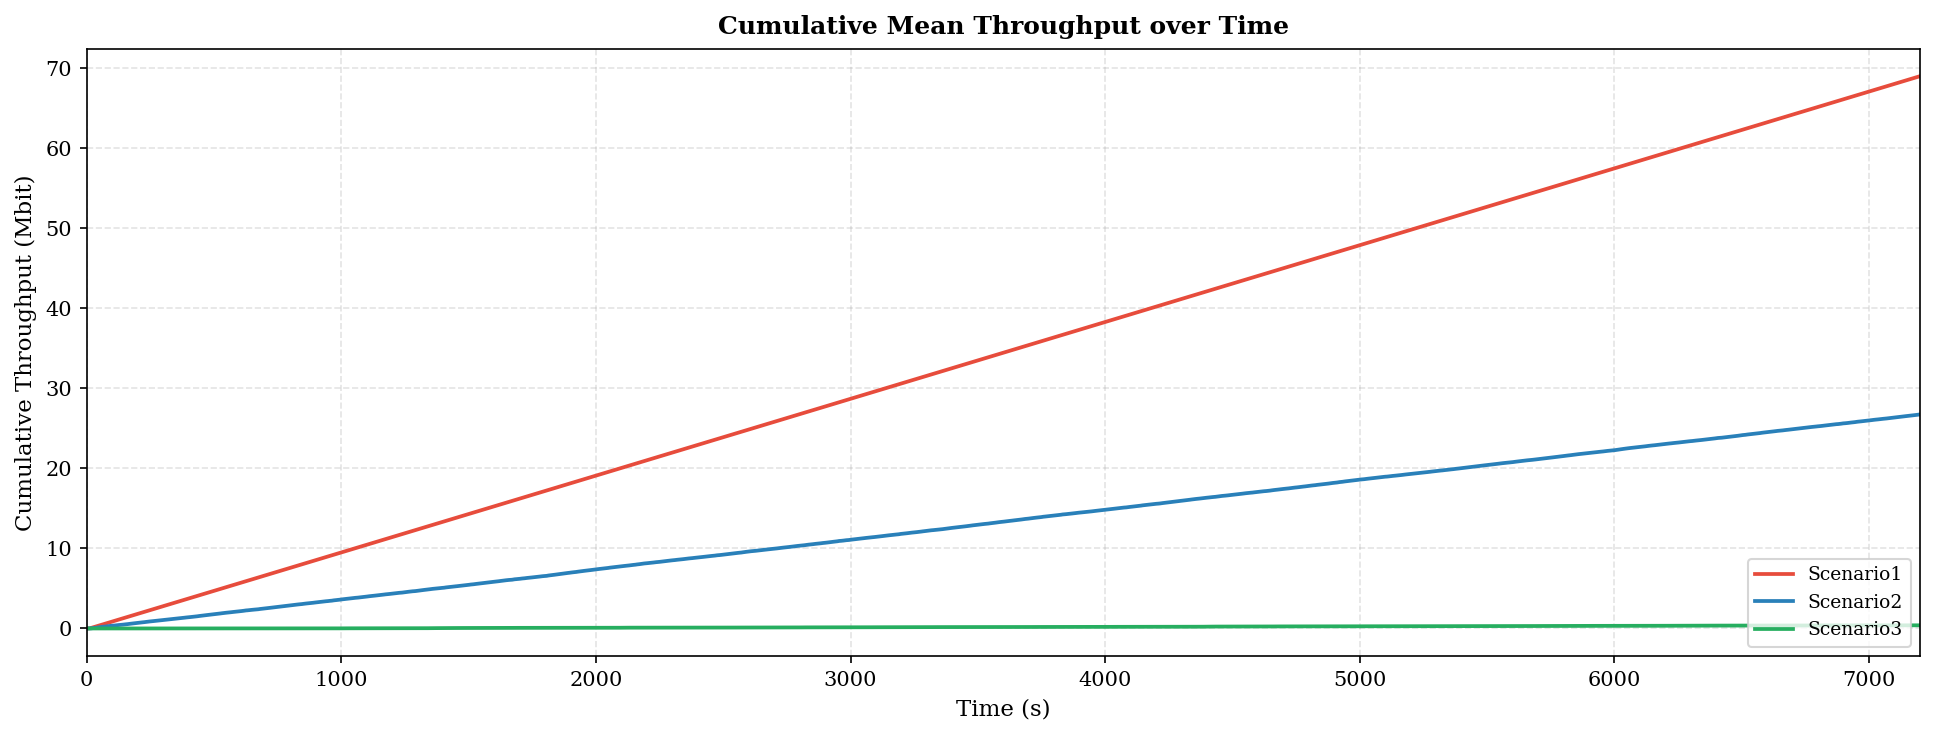

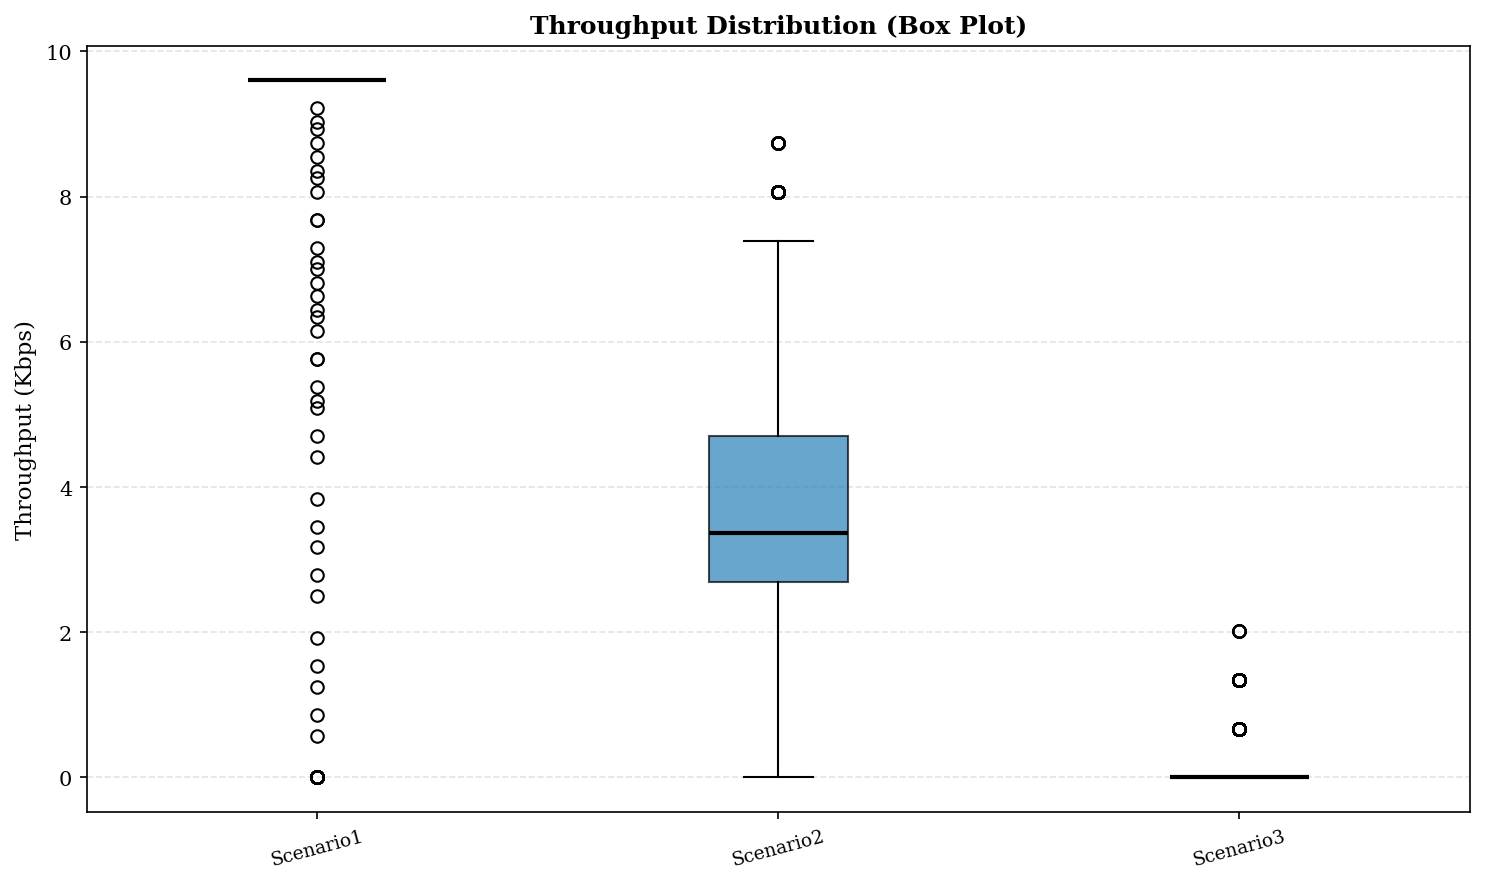

3 server experiments loaded.



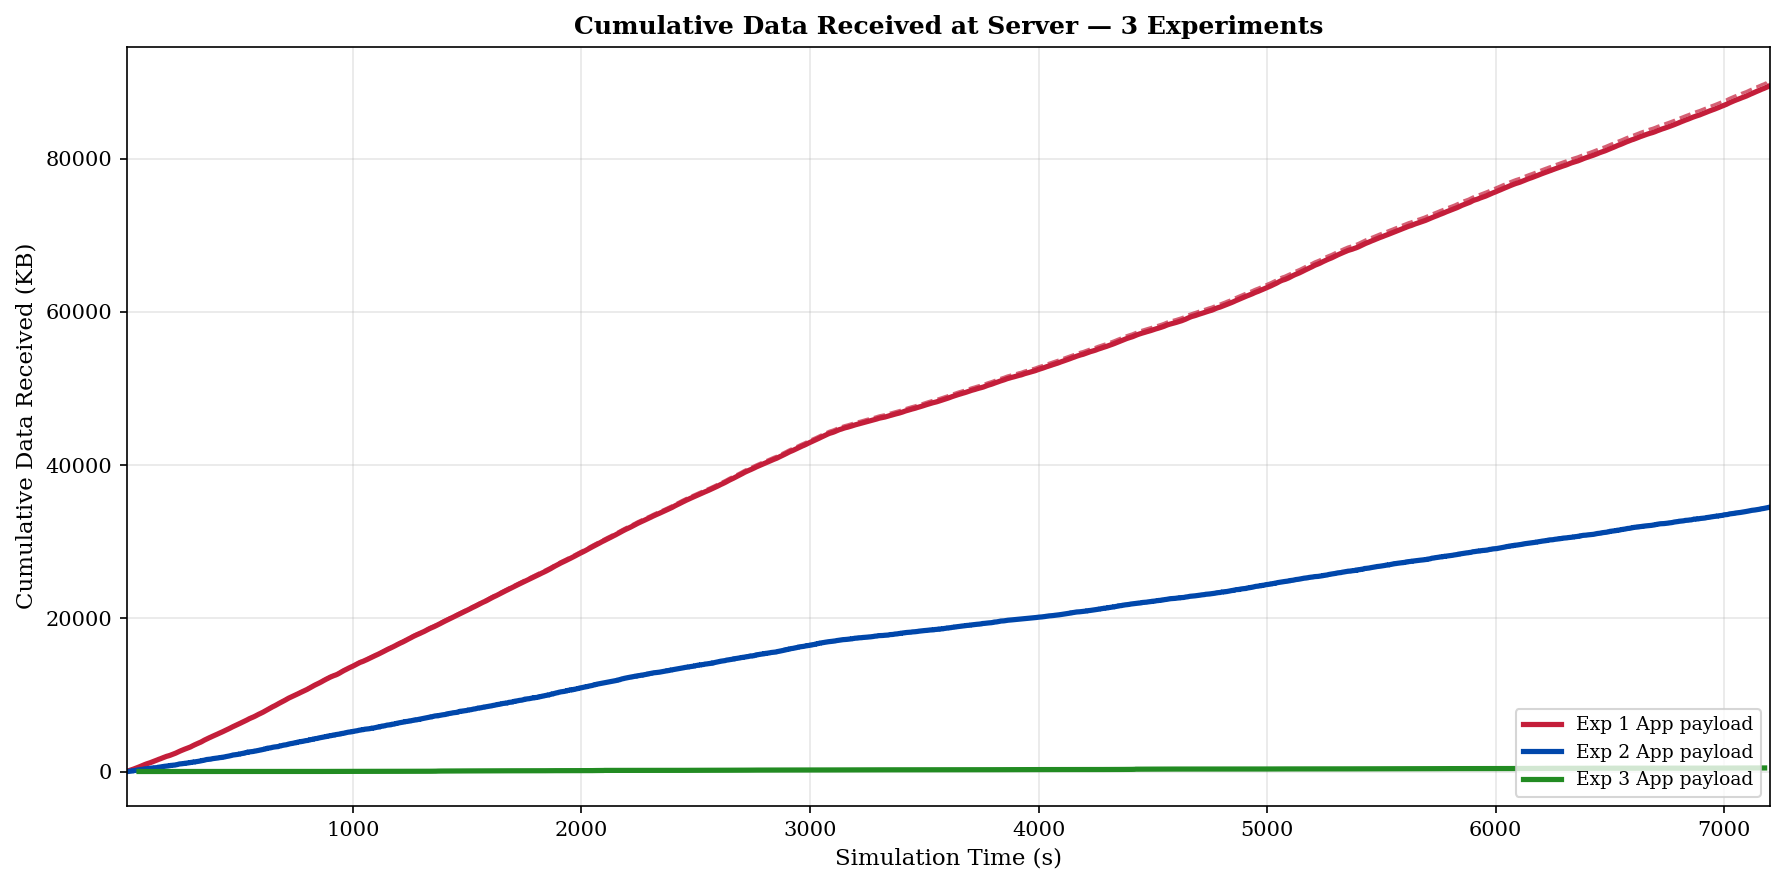

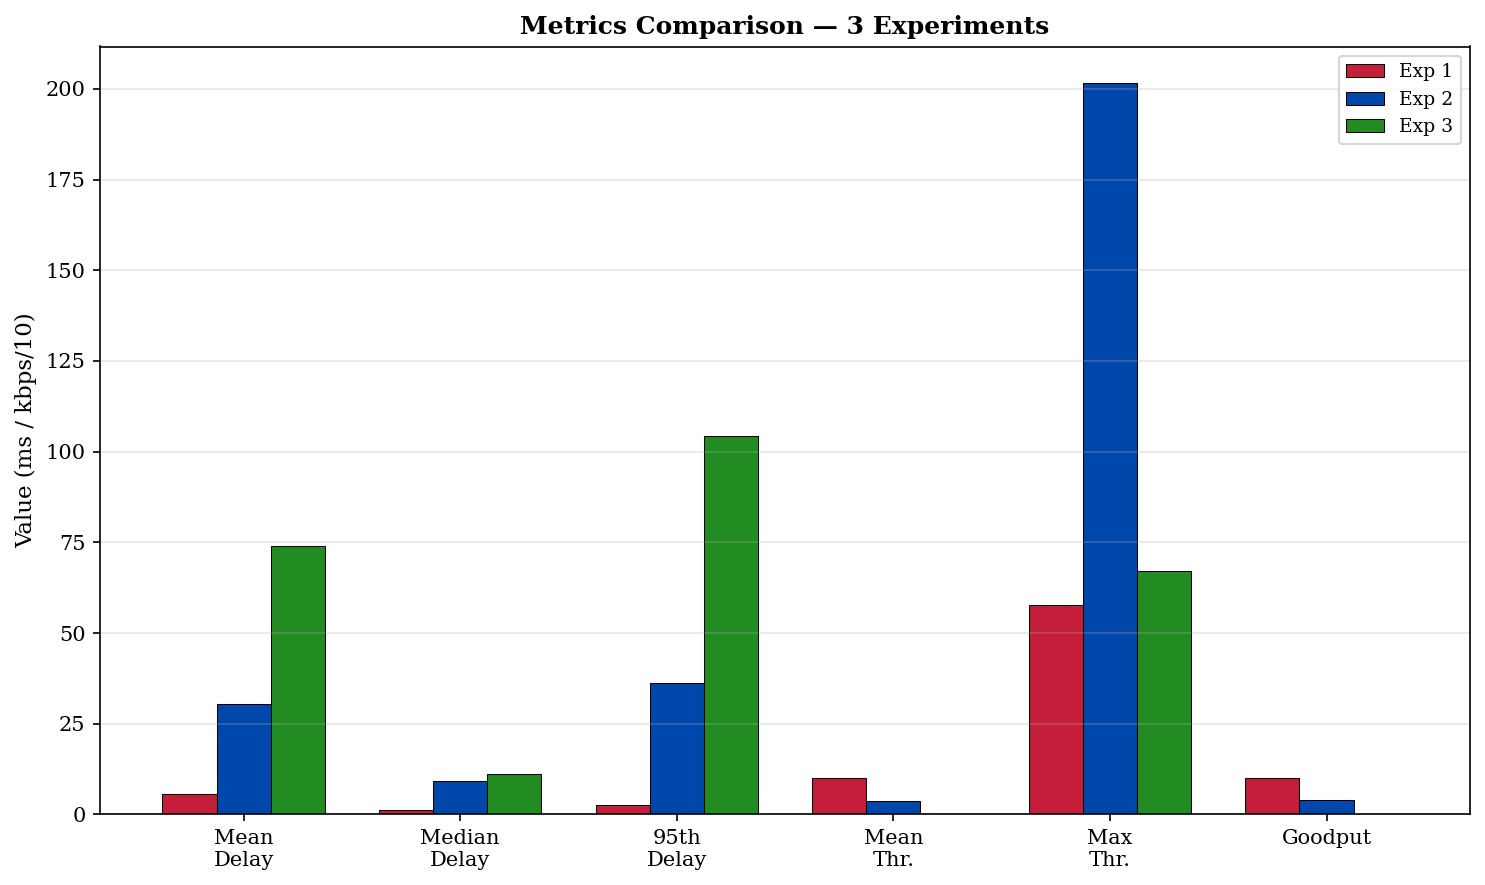

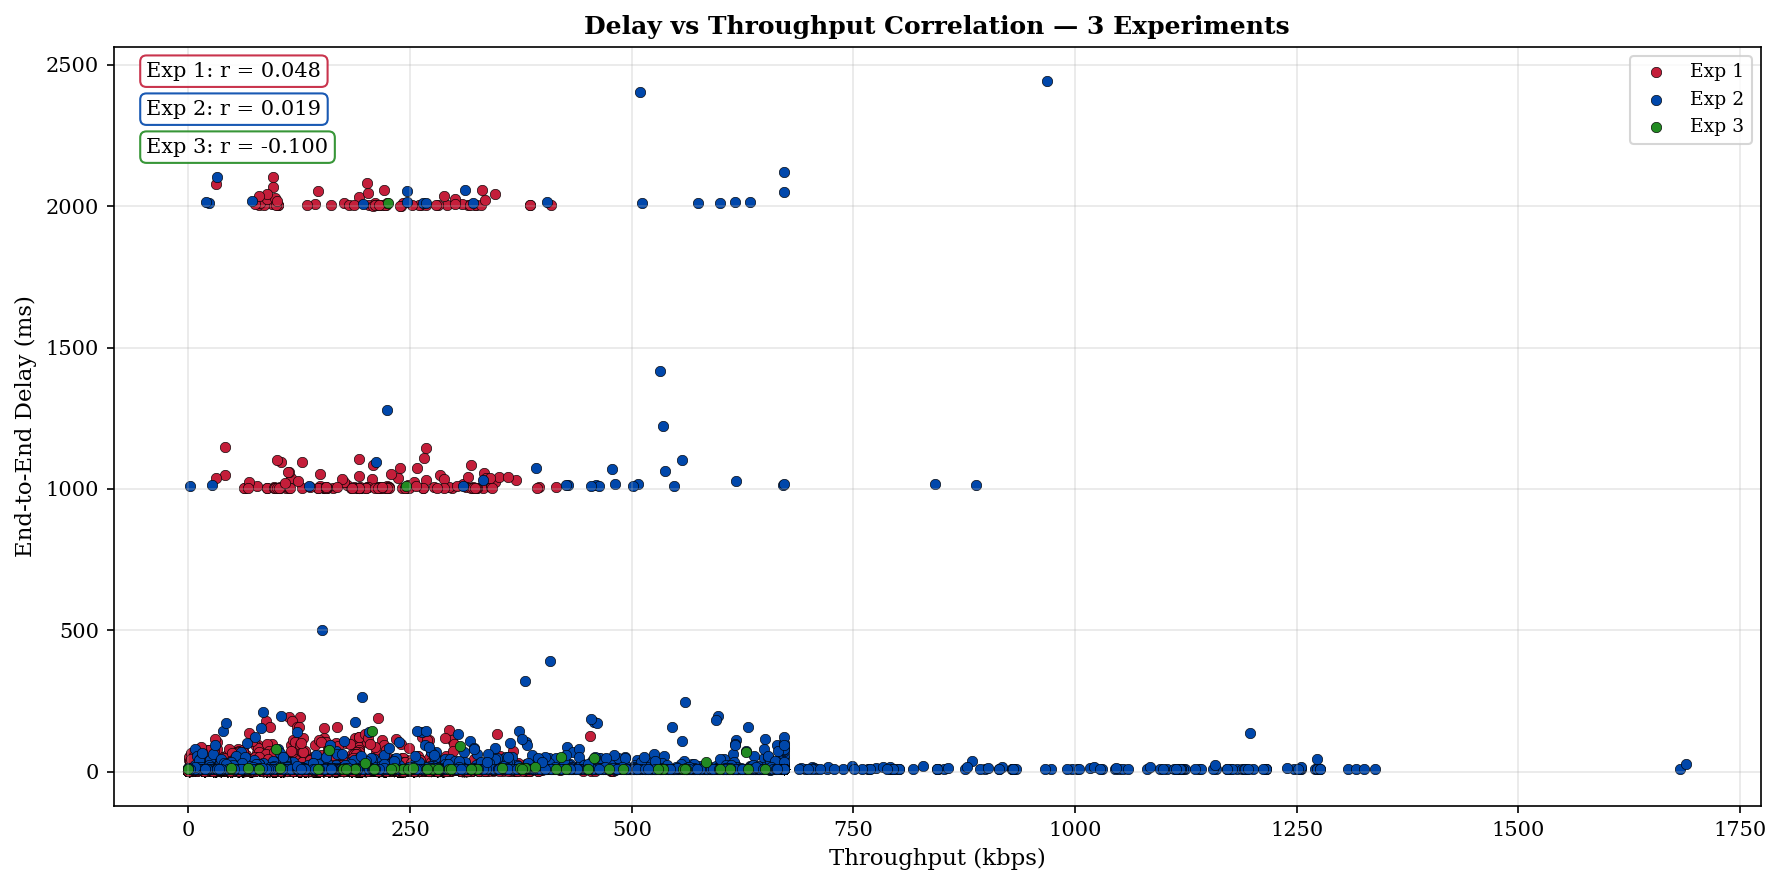

✅ The 6 figures have been generated and saved in /kaggle/working/


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator
import os, warnings
warnings.filterwarnings('ignore')

# ============= COMMON CONFIGURATION =============
output_dir = '/kaggle/working/'
os.makedirs(output_dir, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 10,
    'axes.titlesize': 12, 'axes.labelsize': 11,
    'legend.fontsize': 9, 'figure.dpi': 150,
    'axes.facecolor': 'white', 'figure.facecolor': 'white',
})

# ============= UTILITY FUNCTIONS =============
def parse_vec(df, module, name):
    rows = df[(df['type'] == 'vector') &
              (df['module'] == module) &
              (df['name'] == name)]
    if rows.empty:
        return None, None
    for i in range(len(rows)):
        t_str = rows.iloc[i]['vectime']
        v_str = rows.iloc[i]['vecvalue']
        if pd.notna(t_str) and pd.notna(v_str):
            t = np.array(str(t_str).split(), dtype=float)
            v = np.array(str(v_str).split(), dtype=float)
            return t, v
    return None, None

def throughput_sliding(t_ev, v_bytes, window=5.0, step=0.2, dur=7200.0):
    t_grid = np.arange(0, dur, step)
    kbps = np.zeros(len(t_grid))
    for i, tc in enumerate(t_grid):
        mask = (t_ev >= tc - window/2) & (t_ev < tc + window/2)
        if mask.any():
            kbps[i] = v_bytes[mask].sum() * 8 / window / 1000
    return t_grid, kbps

def extract_vector(df, name_filter):
    vector_row = df[(df['type'] == 'vector') & (df['name'].str.contains(name_filter, na=False, regex=False))]
    if len(vector_row) == 0:
        vector_row = df[df['type'] == 'vector']
    if len(vector_row) == 0:
        return None, None
    row = vector_row.iloc[0]
    times = np.array([float(x) for x in str(row['vectime']).split()])
    values = np.array([float(x) for x in str(row['vecvalue']).split()])
    return times, values

def extract_app_vector(df_recv):
    vector_rows_app = df_recv[(df_recv['type'] == 'vector') & (df_recv['name'].str.contains('packetReceived', na=False))]
    if len(vector_rows_app) >= 2:
        row_app = vector_rows_app.iloc[1]
        t_recv_app = np.array([float(x) for x in str(row_app['vectime']).split()])
        v_recv_app = np.array([float(x) for x in str(row_app['vecvalue']).split()])
        return t_recv_app, v_recv_app
    return None, None

def save_fig(fig, fname):
    fig.savefig(os.path.join(output_dir, fname), dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)

# ================================================================
# PART 1: HOST METRICS (20 Hosts, 3 Scenarios)
# ================================================================
CSV_FILES = [
    '/kaggle/input/datasets/brahimachour2/experinece1/exp1hostsent.csv',
    '/kaggle/input/datasets/brahimachour2/experience2art2/exp2sent.csv',
    '/kaggle/input/datasets/brahimachour2/experinece3art2/exp3sent.csv',
]
EXP_LABELS = ['Scenario1', 'Scenario2', 'Scenario3']
EXP_COLORS_HOST = ['#e74c3c', '#2980b9', '#27ae60']
EXP_MARKERS = ['o', 's', '^']

N_HOSTS = 20
WINDOW = 5.0
DURATION = 7200.0
T_GRID = np.arange(0, DURATION, 0.2)

def zone_of(hid):
    if hid in [0,1,2,3,4]: return 0
    if hid in [5,6,7,8,9]: return 1
    return 2

print("Loading host experiments...")
all_exp_data = []
for exp_idx, csv_path in enumerate(CSV_FILES):
    label = EXP_LABELS[exp_idx]
    if not os.path.exists(csv_path):
        print(f"  ⚠️  {label} - FILE MISSING: {csv_path}")
        continue
    print(f"  ✅ {label}")
    df = pd.read_csv(csv_path)

    per_host_kbps = {}
    for hid in range(N_HOSTS):
        ts, vs = parse_vec(df, f'WifiNetwork.host[{hid}].app[0]',
                           'packetSent:vector(packetBytes)')
        if ts is not None:
            _, ks = throughput_sliding(ts, vs)
            per_host_kbps[hid] = ks
        else:
            per_host_kbps[hid] = np.zeros(len(T_GRID))

    values = np.array(list(per_host_kbps.values()))  # (20, T)
    mean_kbps = values.mean(axis=0)
    std_kbps = values.std(axis=0)
    host_mean = values.mean(axis=1)

    all_exp_data.append({
        'label': EXP_LABELS[exp_idx],
        'color': EXP_COLORS_HOST[exp_idx],
        'marker': EXP_MARKERS[exp_idx],
        'mean_kbps': mean_kbps,
        'std_kbps': std_kbps,
        'host_mean': host_mean,
    })
print(f"{len(all_exp_data)} host experiment(s) loaded.\n")

if len(all_exp_data) == 0:
    print("❌ No host experiment loaded.")
else:
    # ------------------------------------------
    # FIGURE 1 : Mean Throughput ± 1σ
    # ------------------------------------------
    fig, ax = plt.subplots(figsize=(13, 5))
    for e in all_exp_data:
        ax.plot(T_GRID, e['mean_kbps'], color=e['color'], lw=1.8, label=e['label'])
        ax.fill_between(T_GRID,
                        e['mean_kbps'] - e['std_kbps'],
                        e['mean_kbps'] + e['std_kbps'],
                        alpha=0.10, color=e['color'])
    ax.set_title('Mean Throughput ± 1σ (20 Hosts, 3 Scenarios)', fontweight='bold', pad=7)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Throughput (Kbps)')
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.set_xlim(0, DURATION)
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    save_fig(fig, 'fig_mean_throughput_std.png')

    # ------------------------------------------
    # FIGURE 2 : Cumulative Mean Throughput over Time
    # ------------------------------------------
    fig, ax = plt.subplots(figsize=(13, 5))
    for e in all_exp_data:
        cumul = np.cumsum(e['mean_kbps']) * 0.2 / 1000  # Mbit
        ax.plot(T_GRID, cumul, color=e['color'], lw=1.8, label=e['label'])
    ax.set_title('Cumulative Mean Throughput over Time', fontweight='bold', pad=7)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Cumulative Throughput (Mbit)')
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.set_xlim(0, DURATION)
    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    save_fig(fig, 'fig_cumulative_throughput.png')

    # ------------------------------------------
    # FIGURE 3 : Throughput Distribution (Box Plot)
    # ------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 6))
    data_box = [e['mean_kbps'] for e in all_exp_data]
    bp = ax.boxplot(data_box, patch_artist=True, notch=False,
                    medianprops=dict(color='black', lw=2))
    for patch, color in zip(bp['boxes'], EXP_COLORS_HOST[:len(all_exp_data)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels([e['label'] for e in all_exp_data], rotation=15, fontsize=9)
    ax.set_ylabel('Throughput (Kbps)')
    ax.set_title('Throughput Distribution (Box Plot)', fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    plt.tight_layout()
    save_fig(fig, 'fig_boxplot_throughput.png')

# ================================================================
# PART 2: SERVER METRICS (3 Experiments)
# ================================================================
COLORS_SRV = {
    1: {'main': '#C41E3A', 'name': 'Exp 1'},
    2: {'main': '#0047AB', 'name': 'Exp 2'},
    3: {'main': '#228B22', 'name': 'Exp 3'}
}

# Loading server files
df_e2e_1 = pd.read_csv('/kaggle/input/datasets/brahimachour2/experinece1/exp1serverendtoend.csv')
df_recv_1 = pd.read_csv('/kaggle/input/datasets/brahimachour2/experinece1/exp1serverreceive.csv')
df_thr_1 = pd.read_csv('/kaggle/input/datasets/brahimachour2/experinece1/exp1serverthrou.csv')

df_e2e_2 = pd.read_csv('/kaggle/input/datasets/brahimachour2/experience2art2/exp2endto.csv')
df_recv_2 = pd.read_csv('/kaggle/input/datasets/brahimachour2/experience2art2/exp2receive.csv')
df_thr_2 = pd.read_csv('/kaggle/input/datasets/brahimachour2/experience2art2/exp2throu.csv')

df_e2e_3 = pd.read_csv('/kaggle/input/datasets/brahimachour2/experinece3art2/exp3end.csv')
df_recv_3 = pd.read_csv('/kaggle/input/datasets/brahimachour2/experinece3art2/exp3receiv.csv')
df_thr_3 = pd.read_csv('/kaggle/input/datasets/brahimachour2/experinece3art2/exp3thruput.csv')

experiences = {}
for i, (df_e2e, df_recv, df_thr) in enumerate([(df_e2e_1, df_recv_1, df_thr_1),
                                                (df_e2e_2, df_recv_2, df_thr_2),
                                                (df_e2e_3, df_recv_3, df_thr_3)], 1):
    exp = {}
    t_e2e, v_e2e = extract_vector(df_e2e, 'endToEndDelay')
    exp['t_e2e'] = t_e2e
    exp['v_e2e_ms'] = v_e2e * 1000

    t_recv_udp, v_recv_udp = extract_vector(df_recv, 'packetReceived:vector(packetBytes)')
    exp['t_recv_udp'] = t_recv_udp
    exp['v_recv_udp'] = v_recv_udp

    t_recv_app, v_recv_app = extract_app_vector(df_recv)
    exp['t_recv_app'] = t_recv_app
    exp['v_recv_app'] = v_recv_app

    t_thr, v_thr = extract_vector(df_thr, 'throughput')
    exp['t_thr'] = t_thr
    exp['v_thr_kbps'] = v_thr / 1000

    # Cumulatives
    exp['udp_bytes'] = v_recv_udp.cumsum()
    exp['app_bytes'] = v_recv_app.cumsum()

    # Goodput per second (for metric)
    bins = np.arange(10, 7201, 1)
    counts_per_sec, _ = np.histogram(t_recv_app, bins=bins)
    goodput_per_sec = np.zeros_like(counts_per_sec, dtype=float)
    for j in range(len(bins) - 1):
        mask = (t_recv_app >= bins[j]) & (t_recv_app < bins[j+1])
        if np.sum(mask) > 0:
            goodput_per_sec[j] = np.sum(v_recv_app[mask]) * 8
    exp['goodput_kbps'] = goodput_per_sec / 1000
    exp['counts_per_sec'] = counts_per_sec  # for average packet rate

    experiences[i] = exp

print("3 server experiments loaded.\n")

# ------------------------------------------
# FIGURE 4 : Cumulative Data Received at Server
# ------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
for i in range(1, 4):
    exp = experiences[i]
    c = COLORS_SRV[i]['main']
    ax.plot(exp['t_recv_app'], exp['app_bytes'] / 1000, color=c, linewidth=2.5,
            label=f"{COLORS_SRV[i]['name']} App payload")
    ax.plot(exp['t_recv_udp'], exp['udp_bytes'] / 1000, color=c, linewidth=1.5,
            linestyle='--', alpha=0.7)

ax.set_xlabel('Simulation Time (s)')
ax.set_ylabel('Cumulative Data Received (KB)')
ax.set_title('Cumulative Data Received at Server — 3 Experiments', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(10, 7200)
plt.tight_layout()
save_fig(fig, 'fig_cumulative_data_received.png')

# ------------------------------------------
# FIGURE 5 : Metrics Comparison (bar chart)
# ------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
metrics = ['Mean\nDelay', 'Median\nDelay', '95th\nDelay', 'Mean\nThr.', 'Max\nThr.', 'Goodput']
x = np.arange(len(metrics))
width = 0.25

for i in range(1, 4):
    exp = experiences[i]
    values = [
        np.mean(exp['v_e2e_ms']),
        np.median(exp['v_e2e_ms']),
        np.percentile(exp['v_e2e_ms'], 95),
        np.mean(exp['v_thr_kbps']),
        np.max(exp['v_thr_kbps']),
        np.mean(exp['goodput_kbps'])
    ]
    # Normalization for display: delays in ms, throughputs in kbps/10
    values_disp = [values[0], values[1], values[2],
                   values[3]/10, values[4]/10, values[5]/10]
    ax.bar(x + width*(i-2), values_disp, width,
           color=COLORS_SRV[i]['main'], edgecolor='black', linewidth=0.5,
           label=COLORS_SRV[i]['name'])

ax.set_ylabel('Value (ms / kbps/10)')
ax.set_title('Metrics Comparison — 3 Experiments', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
save_fig(fig, 'fig_metrics_comparison.png')

# ------------------------------------------
# FIGURE 6 : Delay vs Throughput Correlation
# ------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
for i in range(1, 4):
    exp = experiences[i]
    c = COLORS_SRV[i]['main']
    v_thr_interp = np.interp(exp['t_e2e'], exp['t_thr'], exp['v_thr_kbps'])
    ax.scatter(v_thr_interp, exp['v_e2e_ms'], c=c, s=25, edgecolors='black',
               linewidth=0.3, label=COLORS_SRV[i]['name'])
    corr = np.corrcoef(v_thr_interp, exp['v_e2e_ms'])[0, 1]
    ax.text(0.02, 0.98 - (i-1)*0.05, f"{COLORS_SRV[i]['name']}: r = {corr:.3f}",
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor=c))

ax.set_xlabel('Throughput (kbps)')
ax.set_ylabel('End-to-End Delay (ms)')
ax.set_title('Delay vs Throughput Correlation — 3 Experiments', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
plt.tight_layout()
save_fig(fig, 'fig_delay_vs_throughput_corr.png')

print("✅ The 6 figures have been generated and saved in", output_dir)